In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [2]:
df = pd.read_csv('../data/cleaned_duolingo.csv')

In [3]:
features = ['mentions_money', 'mentions_update', 'review_length', 'thumbsUpCount', 'is_weekend']
X = df[features]
y = df['is_positive']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

C:\Users\nadun\AppData\Local\Temp\ipykernel_22828\872723873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=importance_df, palette='RdYlGn_r')


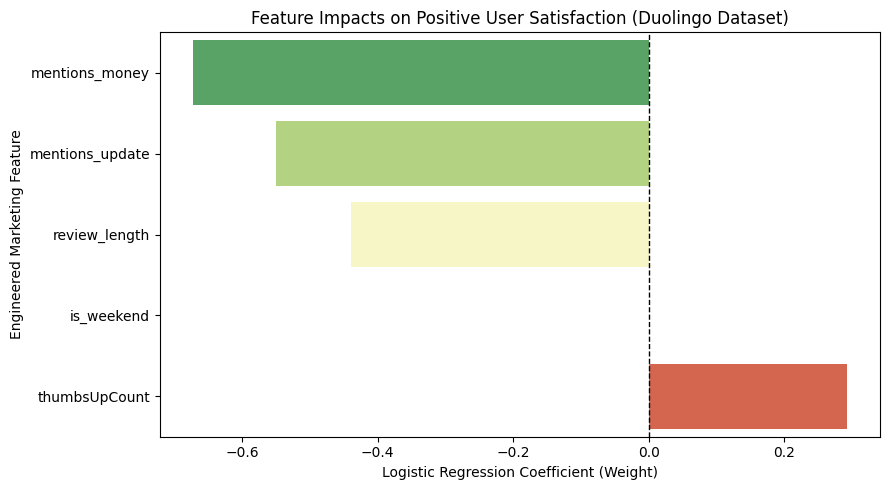

In [7]:
importance_df = pd.DataFrame({'Feature': features, 'Weight': model.coef_[0]}).sort_values(by='Weight')
plt.figure(figsize=(9, 5))
sns.barplot(x='Weight', y='Feature', data=importance_df, palette='RdYlGn_r')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Impacts on Positive User Satisfaction (Duolingo Dataset)', fontsize=12)
plt.xlabel('Logistic Regression Coefficient (Weight)')
plt.ylabel('Engineered Marketing Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [8]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

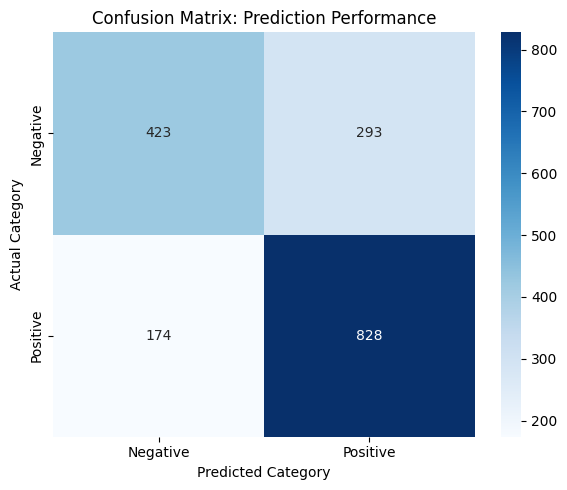

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Prediction Performance', fontsize=12)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

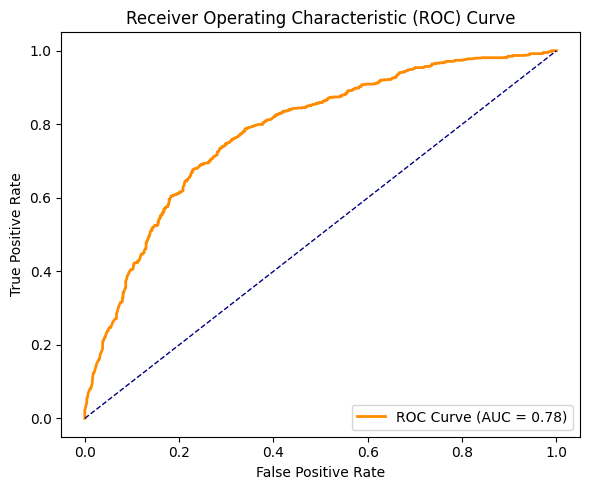

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

In [11]:
# Print formal text report of precision, recall, and f1-scores
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.59      0.64       716
           1       0.74      0.83      0.78      1002

    accuracy                           0.73      1718
   macro avg       0.72      0.71      0.71      1718
weighted avg       0.73      0.73      0.72      1718



In [12]:
import pickle

# Save your trained logistic regression model asset to disk
with open('../src/feature_classification/sentiment_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Save your standard scaler asset to disk to maintain matching text weights
with open('../src/feature_classification/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model assets successfully serialized and saved to disk.")

Model assets successfully serialized and saved to disk.
